In [1]:
# Install the required libraries for GluonTS and its PyTorch Lightning backend
!pip install "lightning[pytorch-extra]" gluonts --upgrade --quiet

# --- Import Necessary Libraries ---
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns

# Import specific GluonTS and PyTorch Lightning components
from gluonts.dataset.common import ListDataset
from gluonts.dataset.field_names import FieldName
from gluonts.torch import DeepAREstimator
from gluonts.evaluation.backtest import make_evaluation_predictions

# Set plotting style
sns.set_style("whitegrid")
print(f"Using Torch version: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.

Found 90 files. Identifying the most common drive model...
--- Automatically selected the most common model: TOSHIBA MG08ACA16TA ---


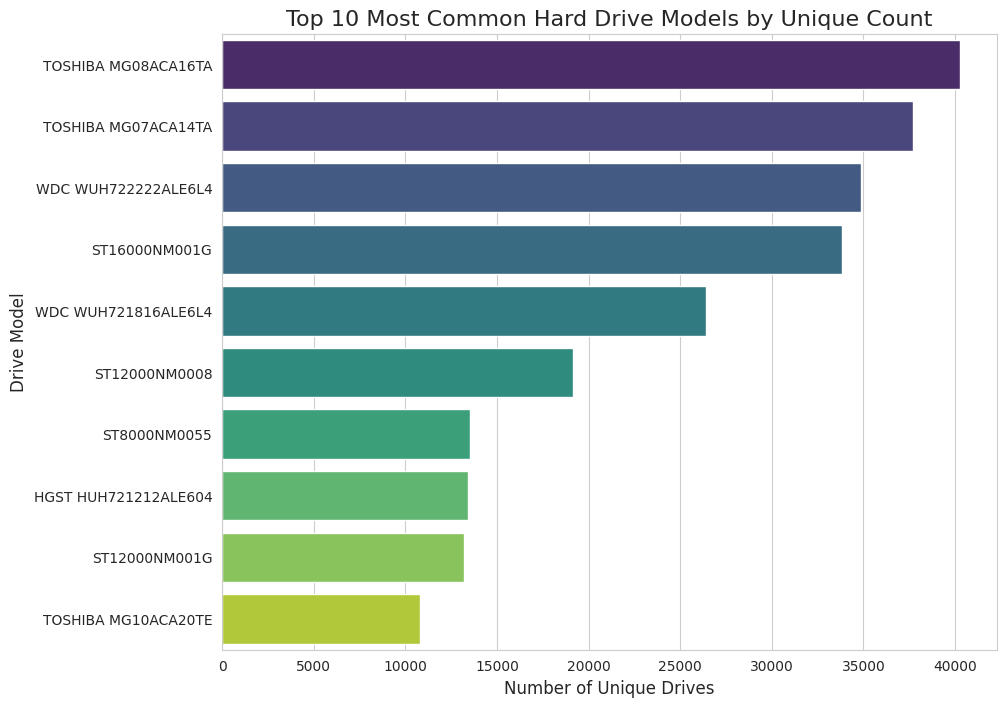

In [2]:
# --- IMPORTANT ---
# This path should point to the PARENT folder containing all your quarterly data folders.
# e.g., /kaggle/input/backblaze-hard-drive-data/
data_path = Path('/kaggle/input/blackblaze-2025-q1/data_Q1_2025') #<-- ADJUST THIS PATH

all_files = list(data_path.glob('**/*.csv'))

if not all_files:
    raise FileNotFoundError(f"No CSV files found at the specified path: {data_path}. Please check the path.")

print(f"Found {len(all_files)} files. Identifying the most common drive model...")

# --- Automated Model Finder ---
model_explorer_cols = ['model', 'serial_number']
explorer_dfs = []
for f in all_files:
    try:
        explorer_dfs.append(pd.read_csv(f, usecols=model_explorer_cols))
    except Exception:
        continue

if not explorer_dfs:
    raise ValueError("Could not read any files to determine the most common model.")
    
explorer_df = pd.concat(explorer_dfs, ignore_index=True)
model_counts = explorer_df.groupby('model')['serial_number'].nunique()
MOST_COMMON_MODEL = model_counts.idxmax()
del explorer_df, explorer_dfs
gc.collect()

print(f"--- Automatically selected the most common model: {MOST_COMMON_MODEL} ---")

# --- Visualization of Top 10 Models ---
plt.figure(figsize=(10, 8))
top_10_models = model_counts.sort_values(ascending=False).head(10)
sns.barplot(x=top_10_models.values, y=top_10_models.index, palette='viridis')
plt.title('Top 10 Most Common Hard Drive Models by Unique Count', fontsize=16)
plt.xlabel('Number of Unique Drives', fontsize=12)
plt.ylabel('Drive Model', fontsize=12)
plt.show()

In [3]:
print(f"Starting data processing for model: {MOST_COMMON_MODEL}...")

features_to_use = [
    'smart_197_raw', # The target feature (must be first)
    'smart_1_raw',
    'smart_5_raw',
    'smart_7_raw',
    'smart_187_raw',
    'smart_188_raw',
    'smart_198_raw'
]
cols_to_load = ['date', 'serial_number', 'model', 'failure'] + features_to_use

processed_dfs = []
for f in all_files:
    try:
        temp_df = pd.read_csv(f, usecols=cols_to_load)
        temp_df = temp_df[temp_df['model'] == MOST_COMMON_MODEL].copy()
        if not temp_df.empty:
            processed_dfs.append(temp_df)
    except Exception as e:
        print(f"Skipping file {f} due to error: {e}")

model_df = pd.concat(processed_dfs, ignore_index=True)
model_df['date'] = pd.to_datetime(model_df['date'])
model_df[features_to_use] = model_df[features_to_use].fillna(0)

del processed_dfs
gc.collect()

print("Data loading and preparation complete.")
print(f"Total records for model {MOST_COMMON_MODEL}: {len(model_df)}")

Starting data processing for model: TOSHIBA MG08ACA16TA...
Data loading and preparation complete.
Total records for model TOSHIBA MG08ACA16TA: 3616128


In [4]:
training_data = []
testing_data = []
drive_groups = model_df.groupby('serial_number')

print(f"Found {len(drive_groups)} unique drives of this model.")
MIN_TS_LENGTH = 10  # A drive needs at least 10 days of history to be useful

for serial, group in drive_groups:
    group = group.sort_values('date').set_index('date')
    if len(group) < MIN_TS_LENGTH:
        continue

    target_values = group[features_to_use[0]].values.astype(np.float32)
    dynamic_features = group[features_to_use[1:]].values.T.astype(np.float32)
    
    gluon_ts = {
        FieldName.START: group.index[0],
        FieldName.TARGET: target_values,
        FieldName.FEAT_DYNAMIC_REAL: dynamic_features,
        FieldName.ITEM_ID: serial
    }
    
    testing_data.append(gluon_ts)
    if group['failure'].sum() == 0:
        training_data.append(gluon_ts)

print(f"Created {len(training_data)} time series for training (healthy drives).")
print(f"Created {len(testing_data)} time series for testing (all drives).")

train_ds = ListDataset(training_data, freq='D')
test_ds = ListDataset(testing_data, freq='D')

del model_df, drive_groups, training_data, testing_data
gc.collect()

Found 40273 unique drives of this model.
Created 40175 time series for training (healthy drives).
Created 40256 time series for testing (all drives).


72

In [5]:
if not train_ds:
    print("\nTraining dataset is empty. Cannot train the model.")
else:
    print("\nConfiguring DeepAR model...")

    estimator = DeepAREstimator(
        freq="D",
        prediction_length=7,
        num_feat_dynamic_real=len(features_to_use) - 1,
        num_layers=2,
        hidden_size=40,
        trainer_kwargs={
            "max_epochs": 15,
            "accelerator": "gpu" if torch.cuda.is_available() else "cpu",
            "devices": 1,
        }
    )

    print("Starting model training...")
    predictor = estimator.train(training_data=train_ds)
    print("Model training complete.")

INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs



Configuring DeepAR model...
Starting model training...


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
2025-09-16 17:07:27.169425: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758042447.393097      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758042447.452256      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name  | Type        | Params | Mode  | In sizes                                                          | Out sizes  
-------------------------------------------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 50: 'train_loss' reached -22.15222 (best -22.15222), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO: Epoch 1, global step 100: 'train_loss' reached -24.18905 (best -24.18905), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO: Epoch 2, global step 150: 'train_loss' reached -25.29101 (best -25.29101), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/epoch=2-step=150.ckpt' as top 1
INFO: Epoch 3, global step 200: 'train_loss' reached -25.76960 (best -25.76960), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/epoch=3-step=200.ckpt' as top 1
INFO: Epoch 4, global step 250: 'train_loss' was not in top 1
INFO: Epoch 5, global step 300: 'train_loss' reached -25.82184 (best -25.82184), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/epoch=5-step=300.ckpt' as top 1
INFO: Epoch 6, global ste

Model training complete.


In [6]:
if 'predictor' in locals():
    print("\nGenerating forecasts for all drives...")
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=test_ds, predictor=predictor, num_samples=100
    )

    forecasts = list(forecast_it)
    tss = list(ts_it)
    anomalies = []

    print("Analyzing forecasts to detect anomalies...")

    target_feature_name = features_to_use[0] 

    for i, (ts, forecast) in enumerate(zip(tss, forecasts)):
        actual_values_df = ts.iloc[[-1]]
        actual = actual_values_df.iloc[0, 0]
        predicted_distribution = forecast.samples[:, 0]
        
        lower_bound = np.percentile(predicted_distribution, 2.5)
        upper_bound = np.percentile(predicted_distribution, 97.5)
        
        # Refined Anomaly Condition: Only flag unexpectedly high values
        if actual > upper_bound:
            anomalies.append({
                'drive_serial': forecast.item_id,
                'feature': target_feature_name,
                'actual_value': actual,
                'predicted_mean': forecast.mean[0],
                'lower_bound': lower_bound,
                'upper_bound': upper_bound
            })

    print(f"\nAnalysis complete. Detected {len(anomalies)} anomalies.")
    anomaly_df = pd.DataFrame(anomalies)
    
    # Sort by severity to see the most critical anomalies first
    anomaly_df = anomaly_df.sort_values(by='actual_value', ascending=False)
else:
    print("\nPredictor not available. Skipping prediction.")
    anomaly_df = pd.DataFrame()


Generating forecasts for all drives...
Analyzing forecasts to detect anomalies...

Analysis complete. Detected 112 anomalies.
